# 02. Exploratory Data Analysis

Sector-level performance metrics computed on winsorized daily returns.

In [1]:
import plotly.io as pio
pio.renderers.default = "png"

import numpy as np
import pandas as pd

import quant_sector_optimizer as qso
from quant_sector_optimizer import plotting

df = qso.load_panel("cleaned_data.parquet")
df = qso.prepare_returns(df)
print(f"{df.Ticker.nunique()} tickers, {len(df):,} rows")

731 tickers, 2,435,677 rows


## Outlier handling — per-asset 6σ winsorization

Per-asset is critical: a single global threshold would either flag thousands
of legitimate moves on volatile names or miss extreme moves on quiet ones.

In [2]:
df["Daily_Return"] = (
    df.groupby("Ticker", observed=True)["Daily_Return"]
      .transform(lambda s: qso.winsorize_returns(s, n_sigma=6.0))
)
print("Winsorized at 6σ per ticker.")

Winsorized at 6σ per ticker.


## Annualized performance per ticker, aggregated by sector

In [3]:
TRADING_DAYS = qso.TRADING_DAYS
RF = qso.DEFAULT_RISK_FREE_RATE

ticker_perf = (
    df.groupby("Ticker", observed=True)
      .agg(mean_daily_return=("Daily_Return", "mean"),
           daily_volatility=("Daily_Return", "std"))
)
ticker_perf["annual_return"] = (1 + ticker_perf["mean_daily_return"]) ** TRADING_DAYS - 1
ticker_perf["annual_volatility"] = ticker_perf["daily_volatility"] * np.sqrt(TRADING_DAYS)
ticker_perf["sharpe_ratio"] = (ticker_perf["annual_return"] - RF) / ticker_perf["annual_volatility"]
ticker_perf = ticker_perf.merge(
    df[["Ticker", "Sector", "Category"]].drop_duplicates(), left_index=True, right_on="Ticker"
)

sector_stats = ticker_perf.groupby("Sector").agg(
    annual_return=("annual_return", "mean"),
    annual_volatility=("annual_volatility", "mean"),
    sharpe_ratio=("sharpe_ratio", "mean"),
    n_tickers=("Ticker", "count"),
).round(4)
sector_stats

,annual_return,annual_volatility,sharpe_ratio,n_tickers
Sector,,,,
basic-materials,0.1708,0.3290,0.4710,67
communication-services,0.2053,0.3490,0.5172,63
consumer-cyclical,0.2409,0.3350,0.7123,66
consumer-defensive,0.1621,0.2369,0.5733,67
energy,0.2898,0.4752,0.4662,68
financial-services,0.2554,0.2928,0.7152,69
healthcare,0.1907,0.2708,0.6336,67
industrials,0.2336,0.2795,0.7663,67
real-estate,0.1467,0.2439,0.5146,68


## Cumulative performance per sector

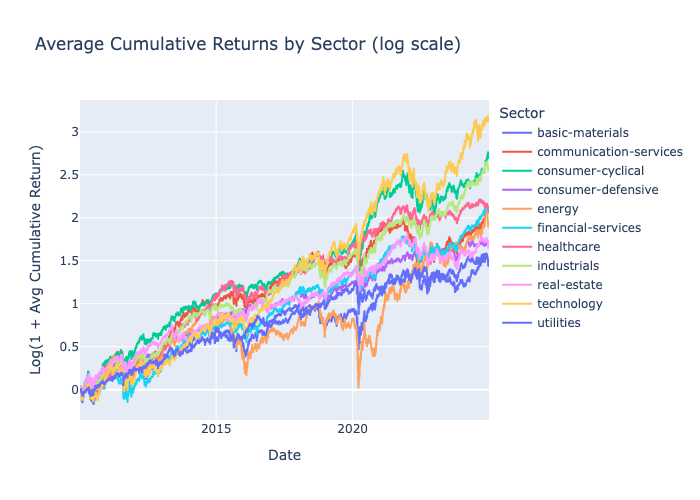

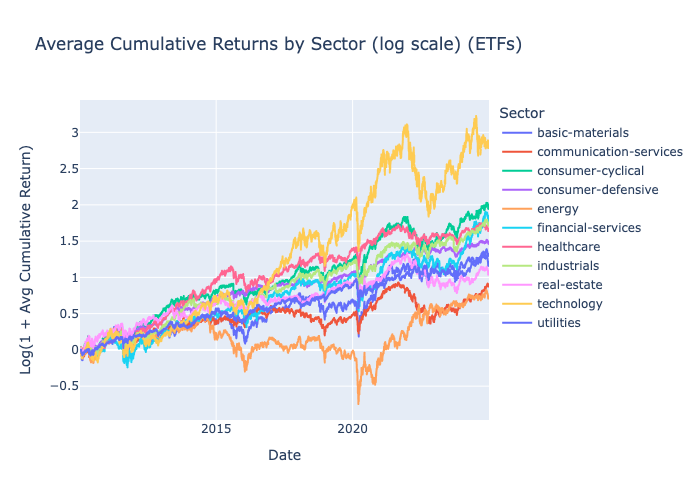

In [4]:
plotting.plot_sector_cumulative(df).show()
plotting.plot_sector_cumulative(df[df["Category"] == "etfs"], title_suffix="(ETFs)").show()